In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder

In [145]:
df = pd.read_csv(r'../data/raw/weatherHistory.csv')

In [146]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [147]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


In [148]:
df.shape

(96453, 12)

In [149]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='str')

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 16.3 MB


In [151]:
print(df.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [152]:
df = df.dropna()

In [153]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.shape

(24, 12)

In [154]:
df = df.drop_duplicates()

In [155]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,95912.000000,95912.000000,95912.000000,95912.000000,95912.000000,95912.000000,95912.0,95912.000000
mean,11.937975,10.859194,0.734844,10.806764,187.506986,10.362306,0.0,1003.146959
std,9.569620,10.716711,0.195717,6.920504,107.378309,4.174204,0.0,117.291484
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.594444,2.272222,0.600000,5.812100,116.000000,8.355900,0.0,1011.890000
50%,12.022222,12.022222,0.780000,9.933700,180.000000,10.046400,0.0,1016.420000
75%,18.844444,18.844444,0.890000,14.135800,290.000000,14.812000,0.0,1021.050000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


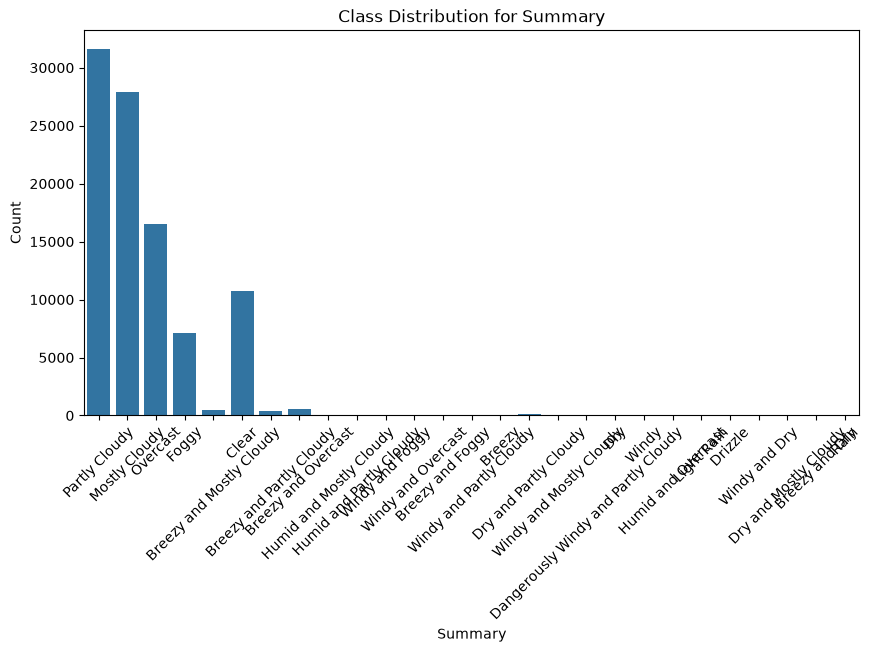

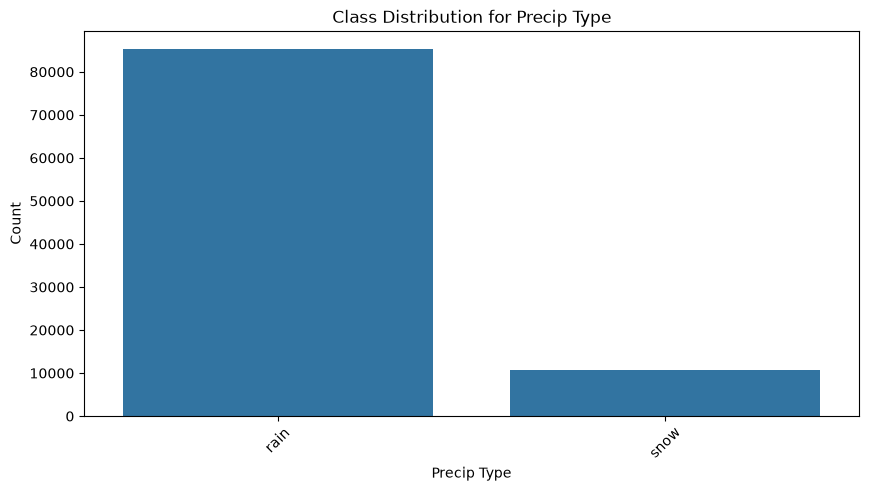

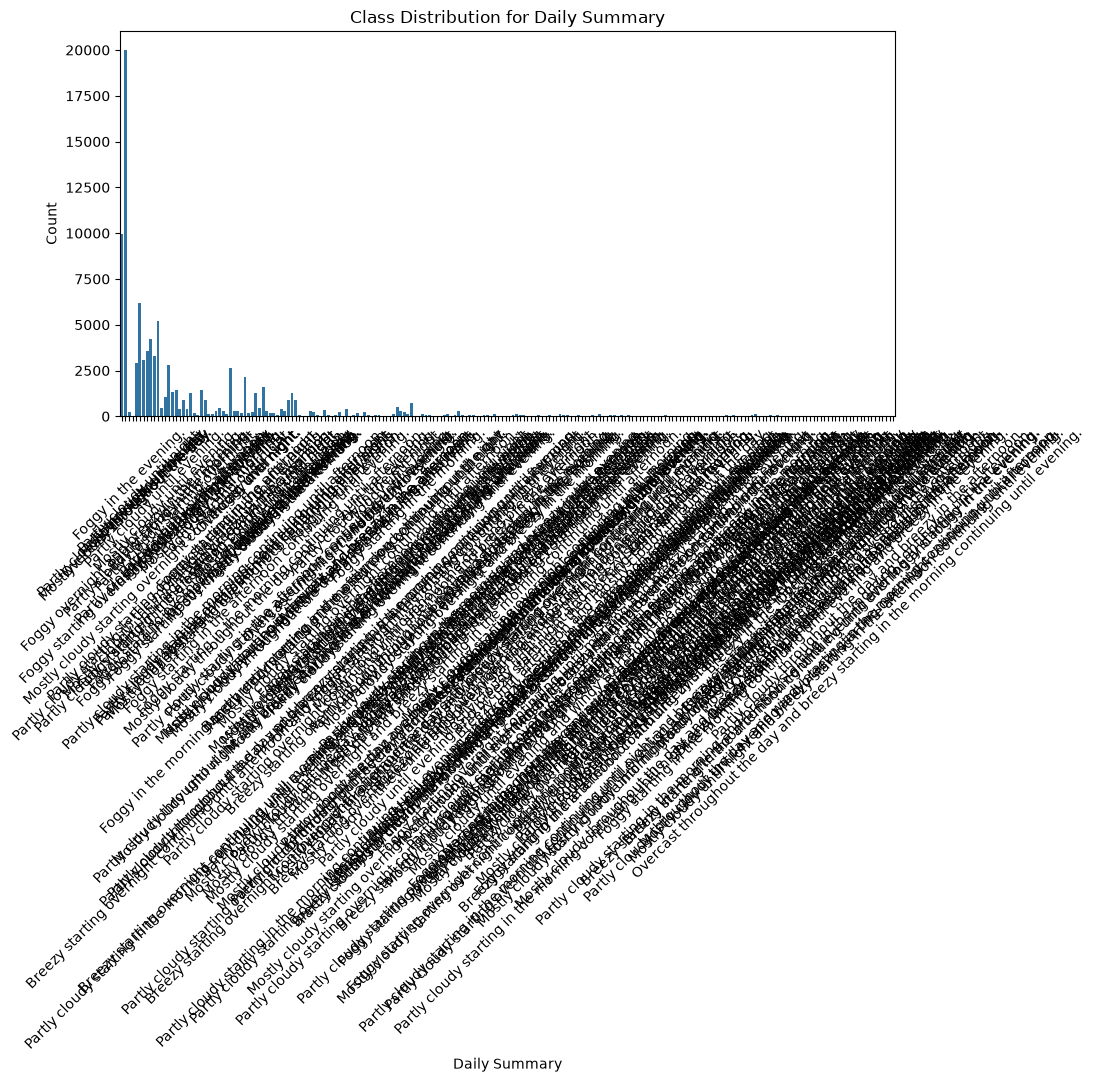

In [156]:
categorical_cols = ['Summary', 'Precip Type', 'Daily Summary']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)

    plt.title(f"Class Distribution for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

Daily Summary Convertion

In [157]:
print(df['Daily Summary'].value_counts().unique().sum())

84464


In [158]:
def simplify_weather(summary):
    summary = summary.lower()

    if 'rain' in summary or 'drizzle' in summary:
        return 'Rainy'
    elif 'foggy' in summary:
        return 'Foggy'
    elif 'cloudy' in summary or 'overcast' in summary:
        return 'Cloudy'
    elif 'clear' in summary:
        return 'Clear'
    elif 'windy' in summary or 'breezy' in summary:
        return 'Windy'
    else:
        return 'Other'


Create Daily Summury Simplified from 85485 to 5 categories

In [159]:
df['Daily Summary'] = df['Daily Summary'].apply(simplify_weather)

In [160]:
print(df['Daily Summary'].value_counts().tolist())

[75878, 18935, 864, 163, 72]


In [161]:
display(df['Daily Summary'].unique())

<ArrowStringArray>
['Cloudy', 'Foggy', 'Clear', 'Rainy', 'Windy']
Length: 5, dtype: str

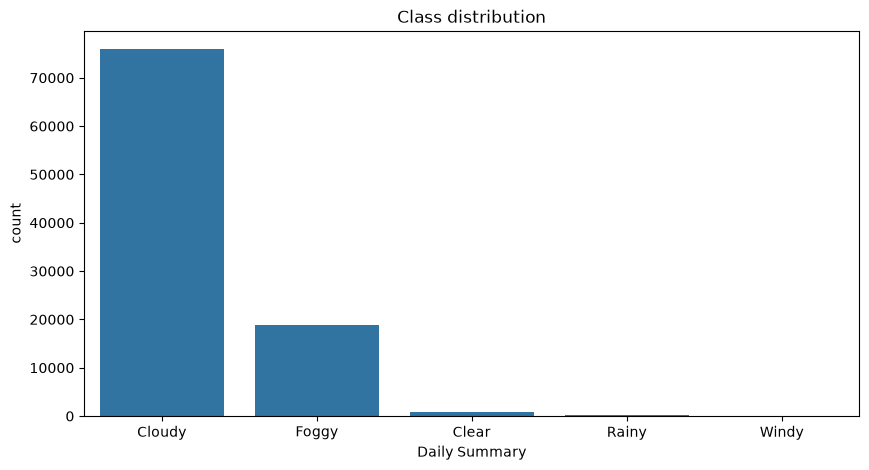

In [162]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Daily Summary'])
plt.title("Class distribution")
plt.show()

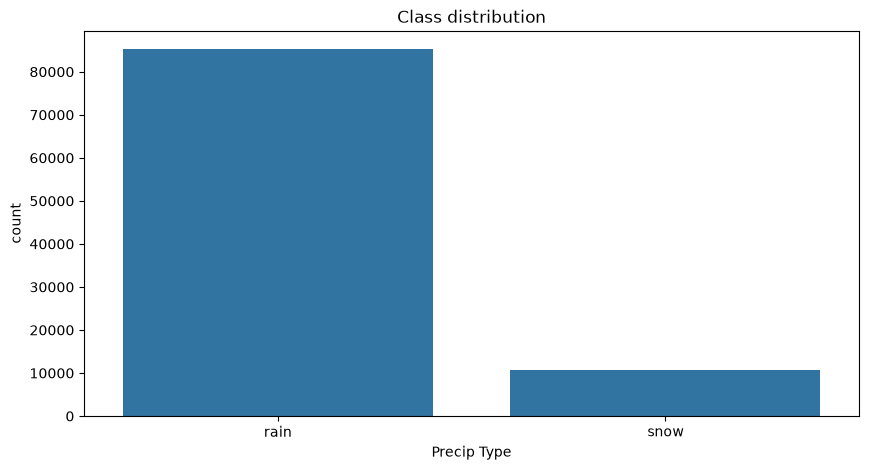

In [163]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['Precip Type'])
plt.title("Class distribution")
plt.show()

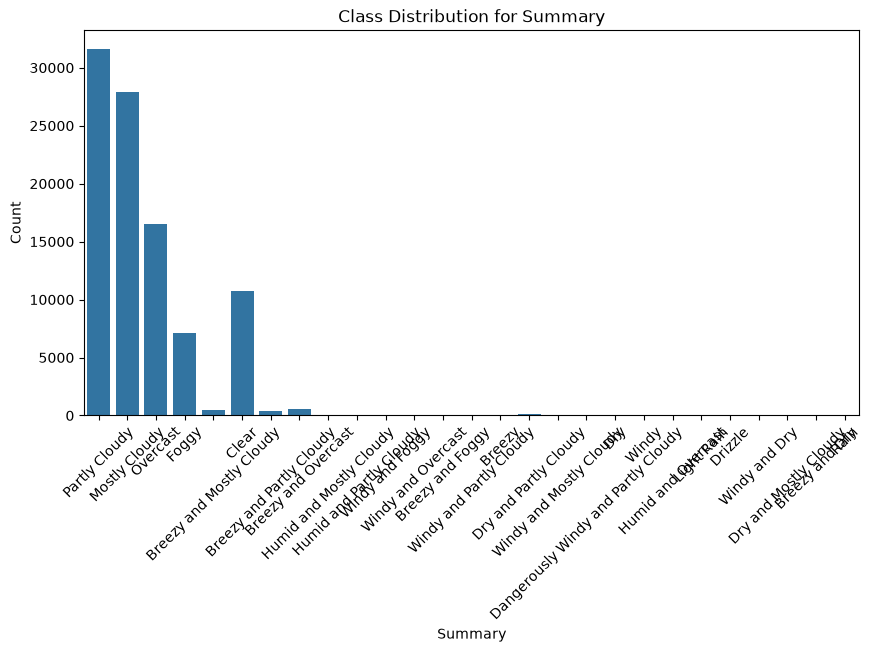

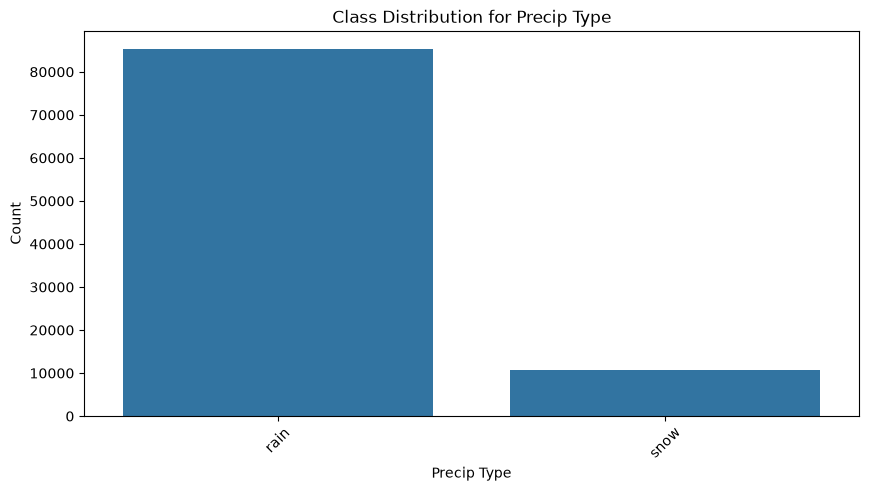

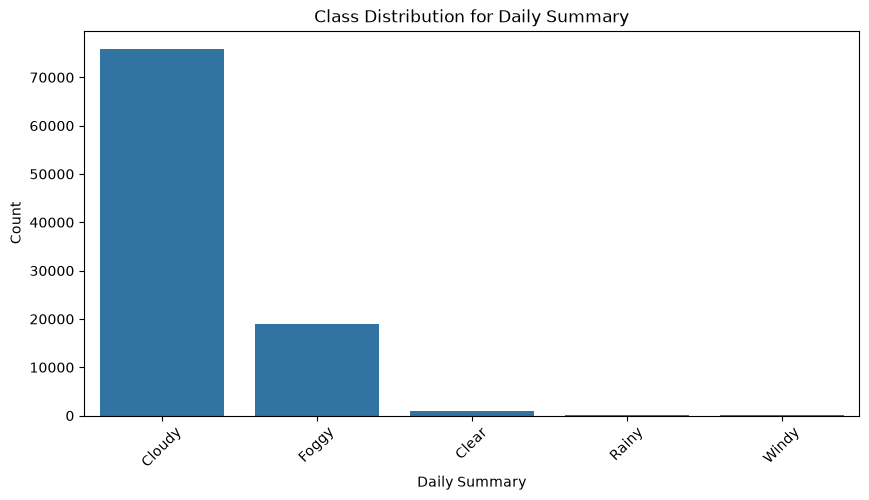

In [164]:
categorical_cols = ['Summary', 'Precip Type', 'Daily Summary']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)

    plt.title(f"Class Distribution for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

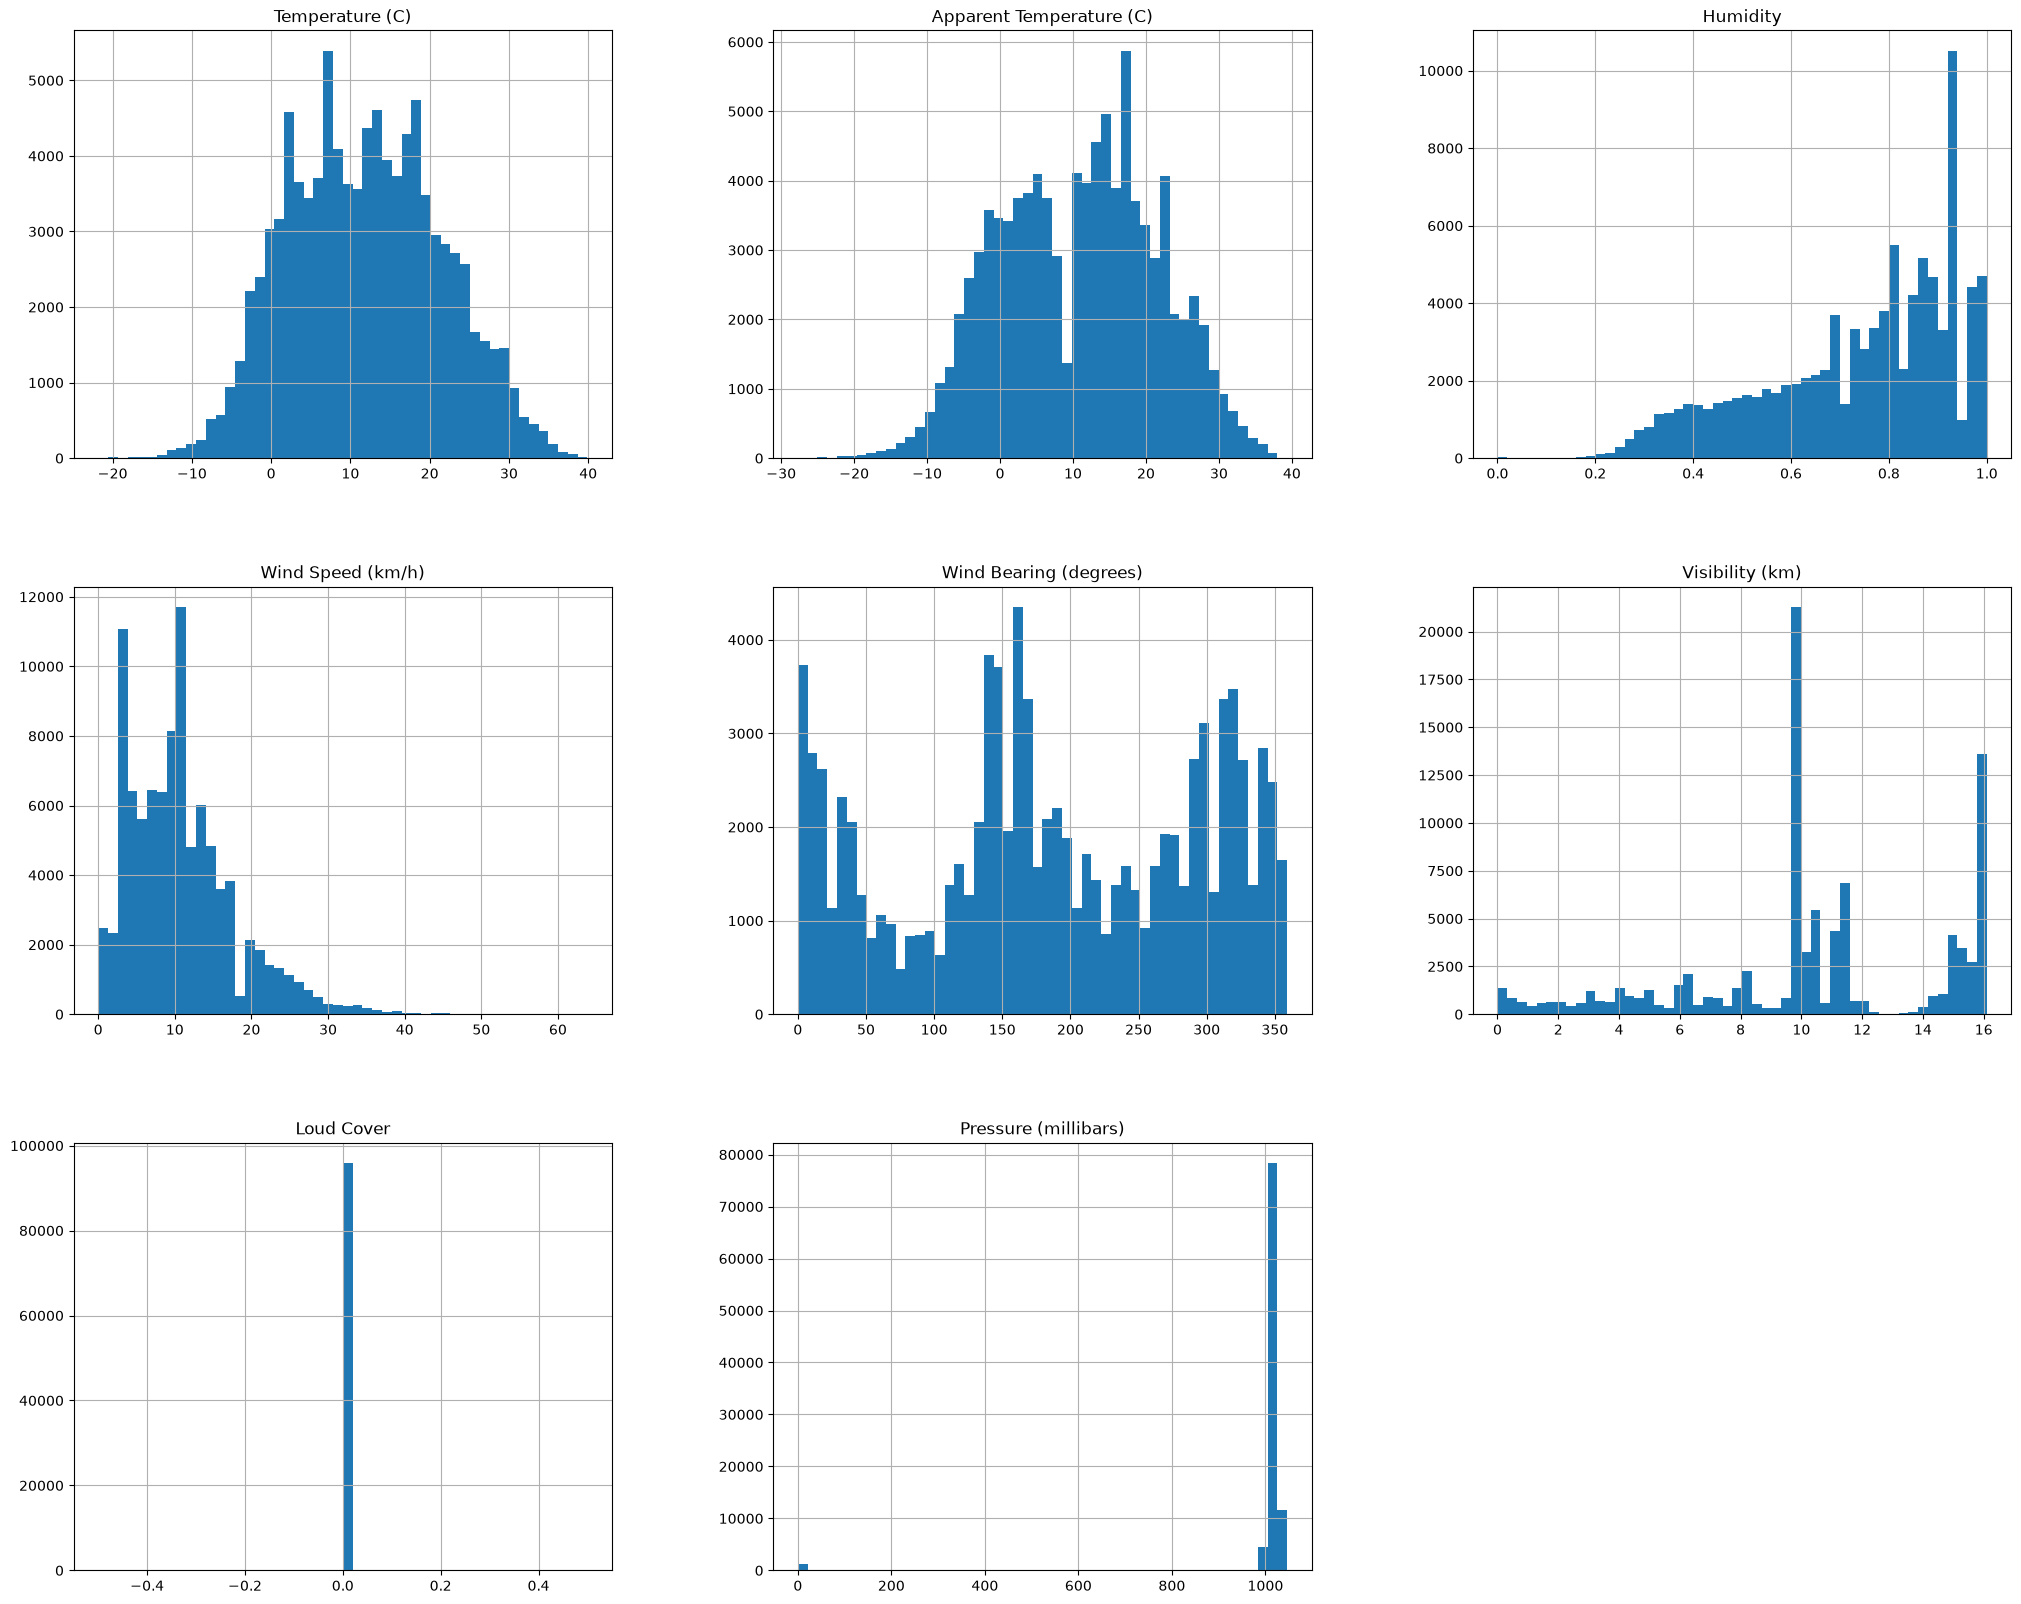

In [165]:
df.hist(bins=50, figsize=(25,20))
plt.show()

In [166]:
numerical_cols = df.select_dtypes(include='number').columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

condition = ~((df[numerical_cols]<(Q1-1.5*IQR)) | (df[numerical_cols]>(Q3+1.5*IQR))).any(axis=1)

df_cleaned = df[condition]

print(df_cleaned.shape)

(88721, 12)


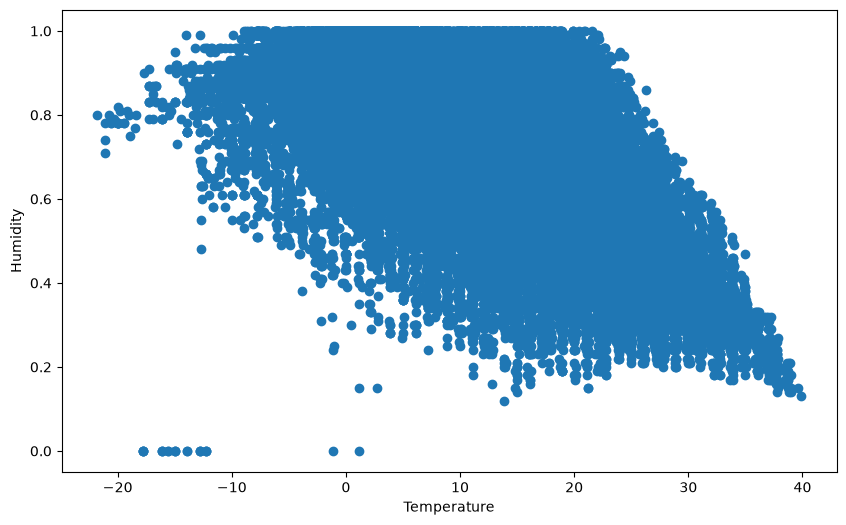

In [167]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['Temperature (C)'], df['Humidity'])
ax.set_xlabel('Temperature')
ax.set_ylabel('Humidity')
plt.show()

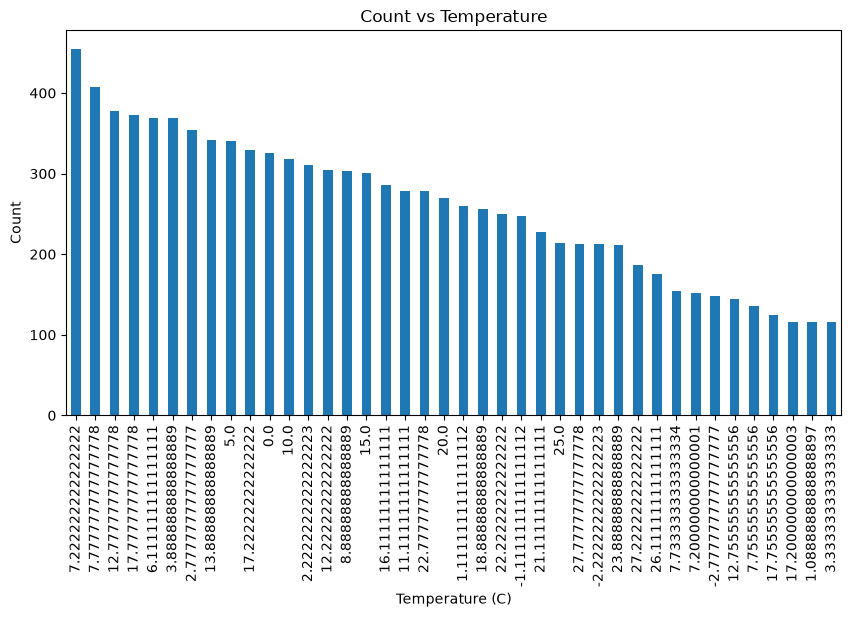

In [190]:
df['Temperature (C)'].value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
plt.title('Count vs Temperature')
plt.ylabel('Count')
plt.xlabel('Temperature (C)')
plt.show()

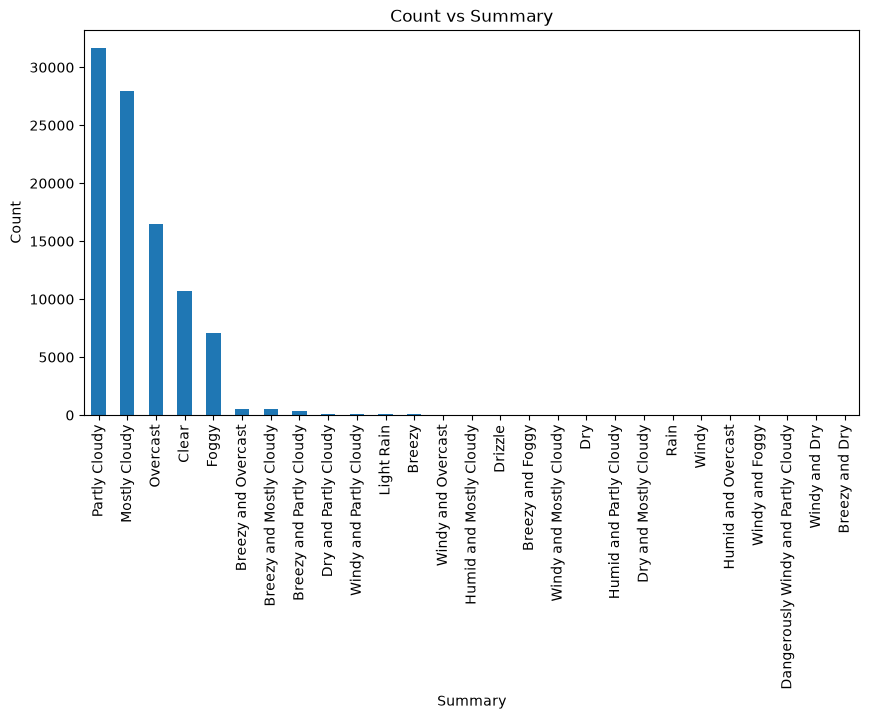

In [191]:
df['Summary'].value_counts().nlargest(50).plot(kind='bar', figsize=(10,5))
plt.title('Count vs Summary')
plt.ylabel('Count')
plt.xlabel('Summary')
plt.show()

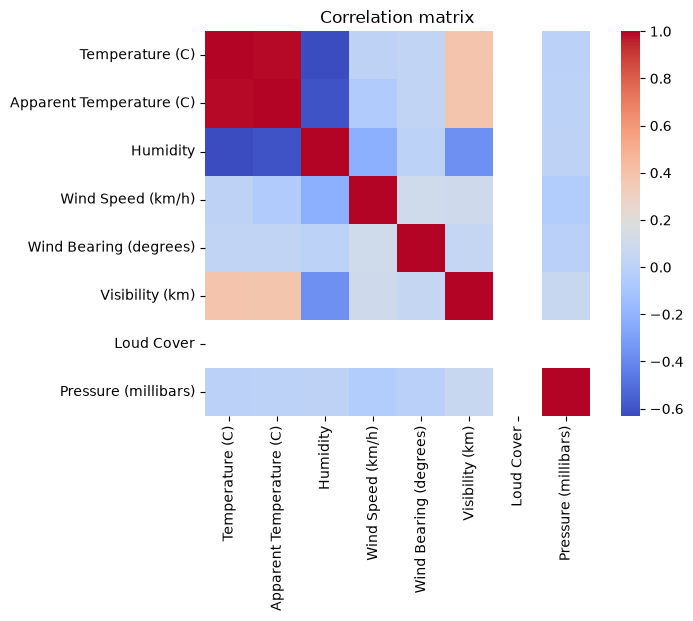

In [170]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation matrix")
plt.show()

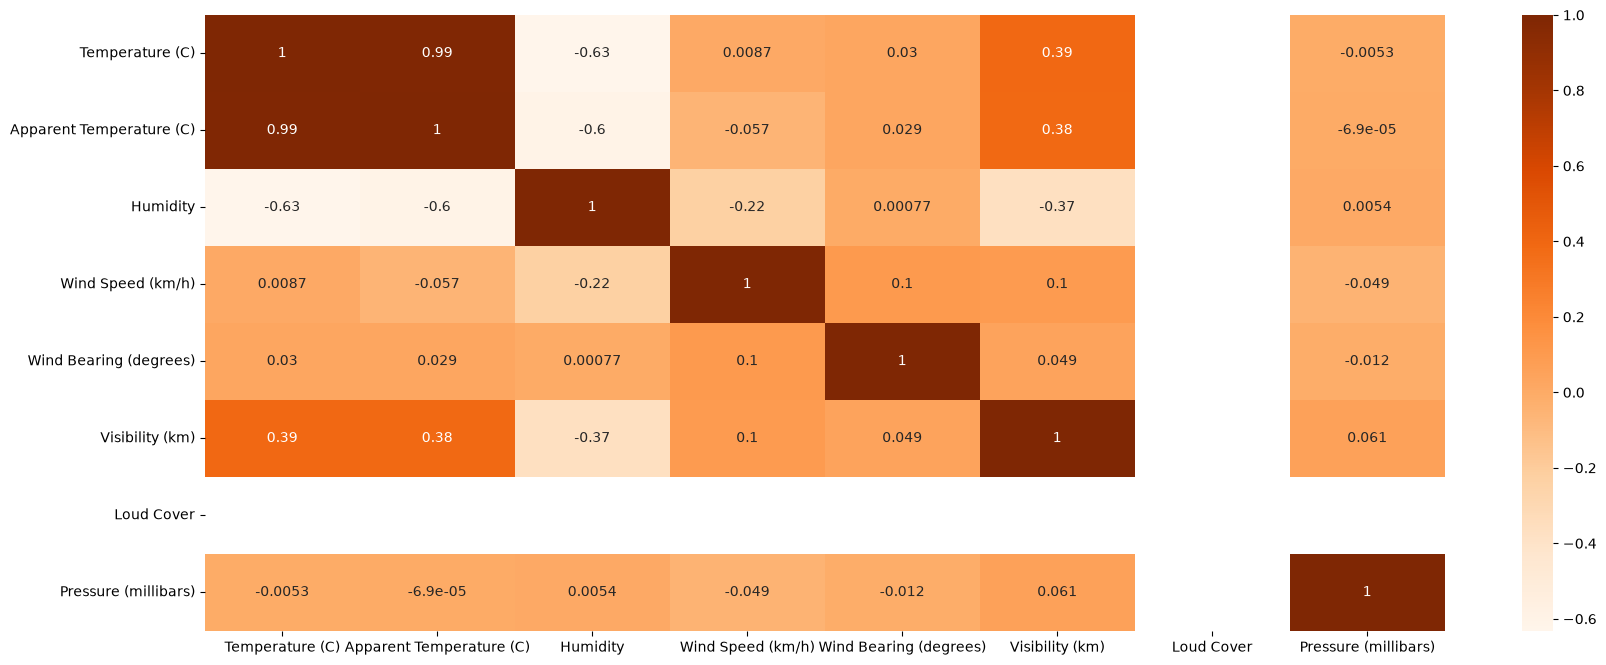

In [171]:
plt.figure(figsize=(20, 8))
hmp = df.corr(numeric_only=True)
sns.heatmap(hmp, cmap='Oranges', annot=True)
plt.show()

In [172]:
column_names = df.columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

C:\Users\Thanuja\AppData\Local\Temp\ipykernel_13512\1093590612.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


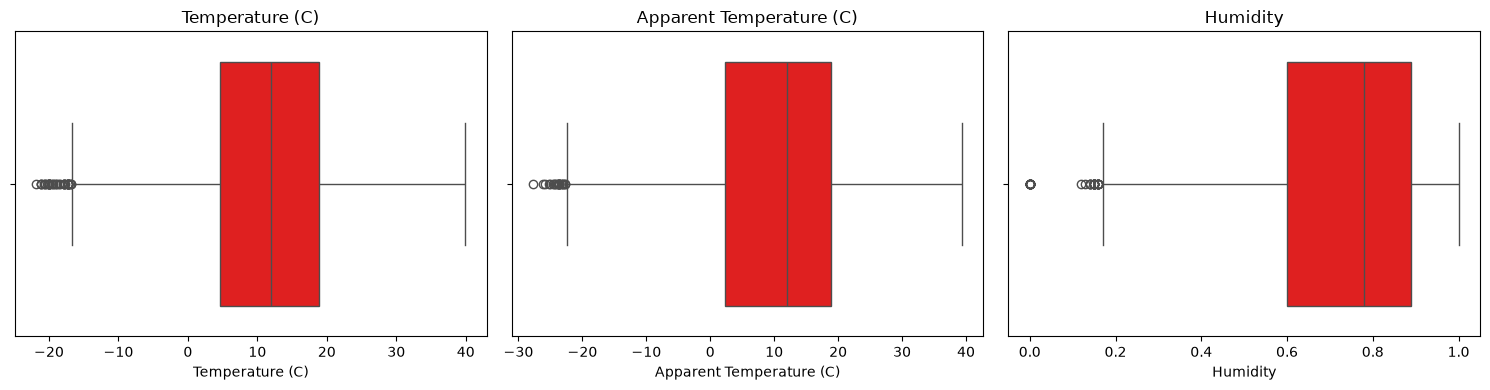

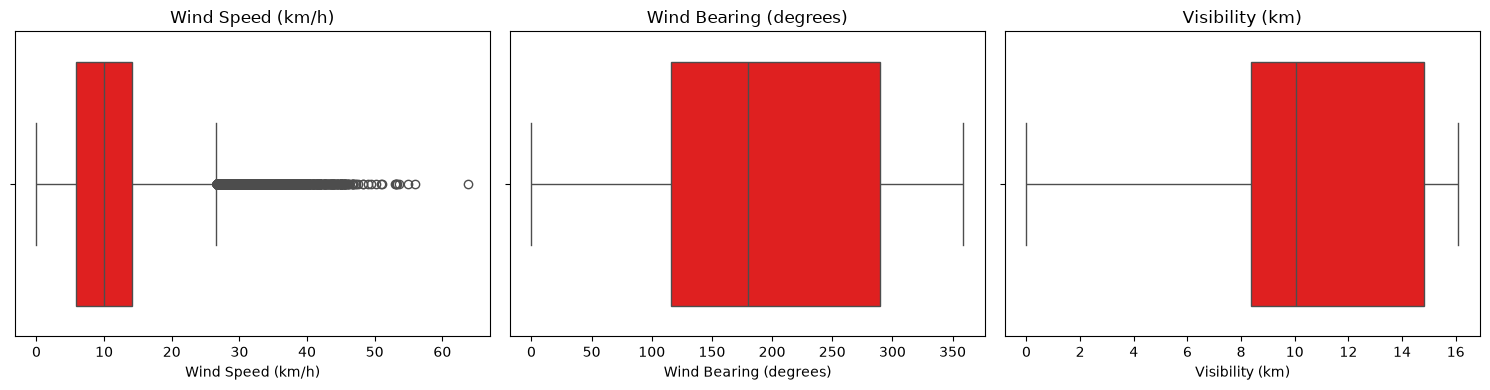

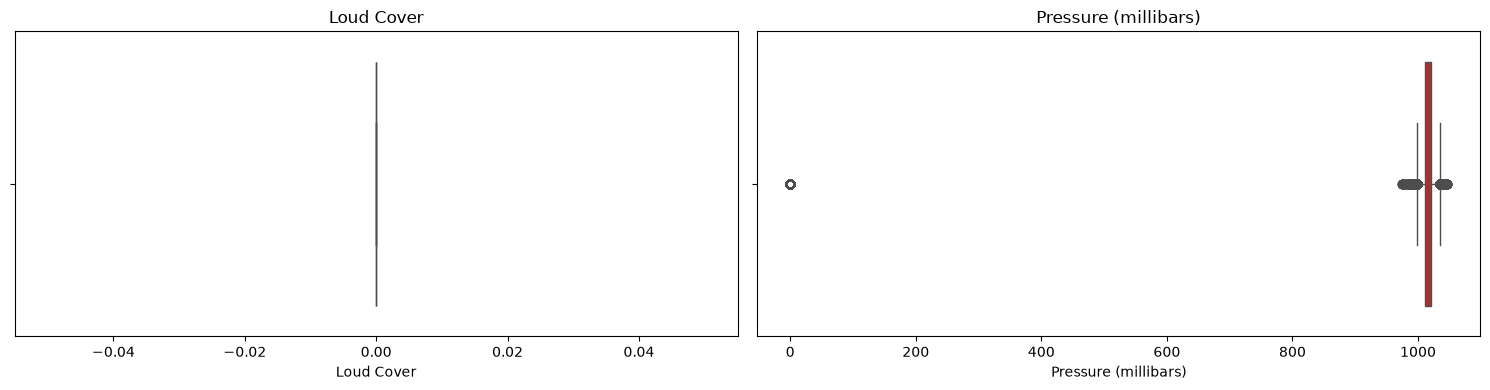

In [173]:
box_plt_cols = numerical_cols[0:]

n_cols = 3

for start in range(0, len(box_plt_cols), n_cols):
    cols = box_plt_cols[start:start + n_cols]

    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, cols):
        sns.boxplot(x=df[col], color='red', ax=ax)
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

    plt.close(fig)

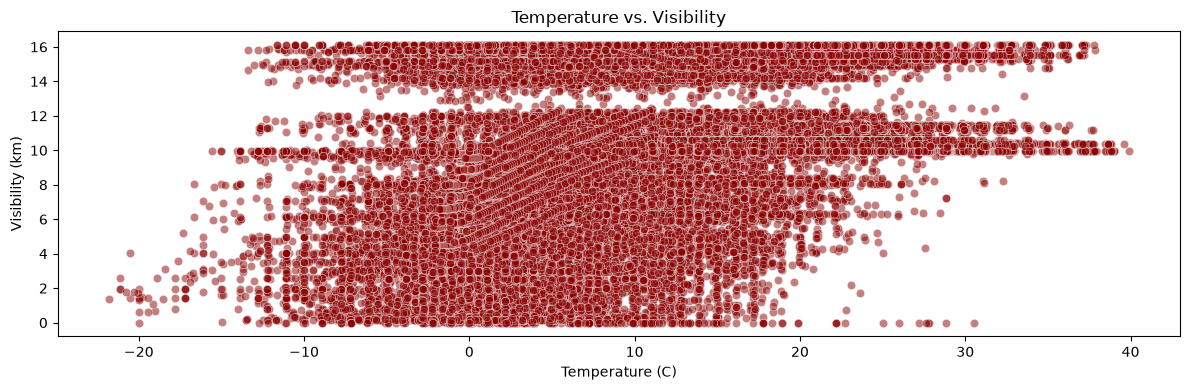

In [174]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature (C)', y='Visibility (km)', alpha=0.5, color='darkred')
plt.title("Temperature vs. Visibility")

plt.tight_layout()
plt.show()

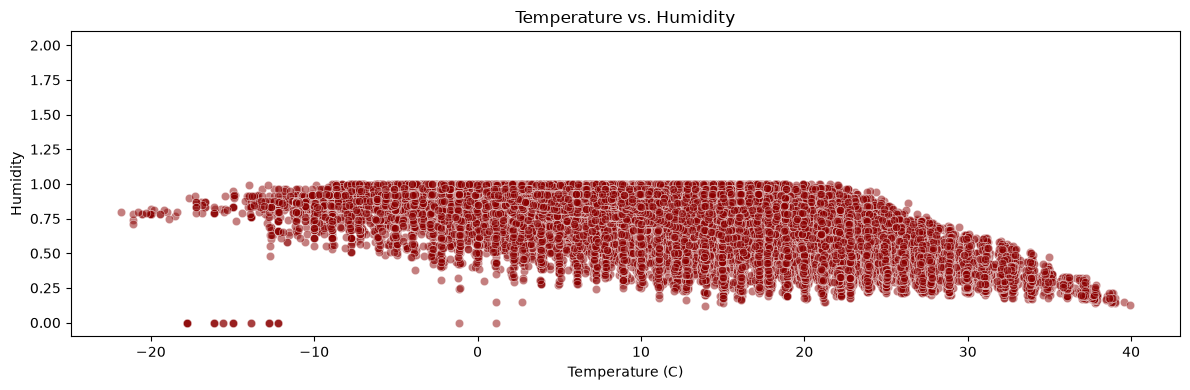

In [175]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature (C)', y='Humidity', alpha=0.5, color='darkred')
plt.title("Temperature vs. Humidity")

plt.tight_layout()
plt.show()

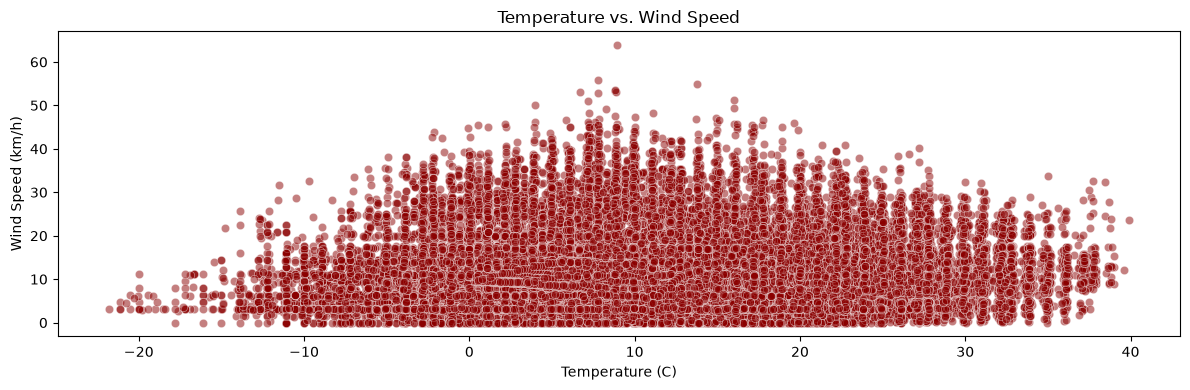

In [176]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature (C)', y='Wind Speed (km/h)', alpha=0.5, color='darkred')
plt.title("Temperature vs. Wind Speed")

plt.tight_layout()
plt.show()

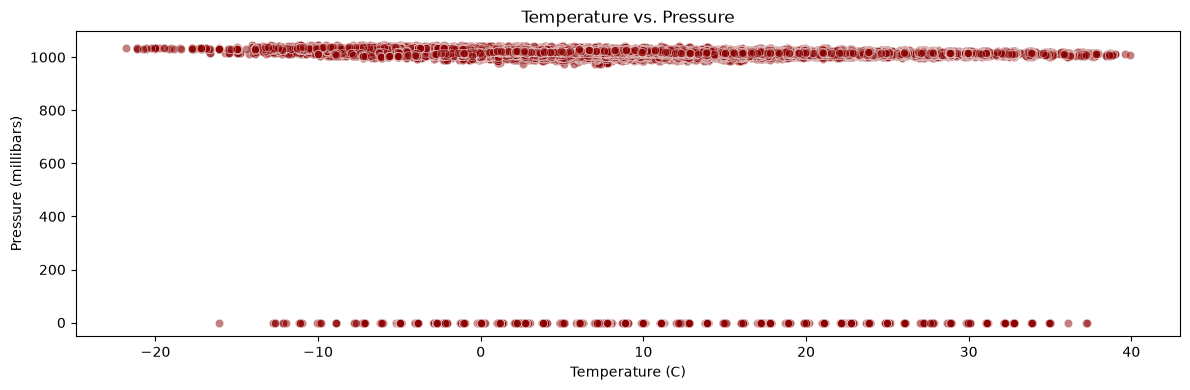

In [177]:
plt.figure(figsize=(12, 4))

plt.plot(1, 2, 2)
sns.scatterplot(data=df, x='Temperature (C)', y='Pressure (millibars)', alpha=0.5, color='darkred')
plt.title("Temperature vs. Pressure")

plt.tight_layout()
plt.show()

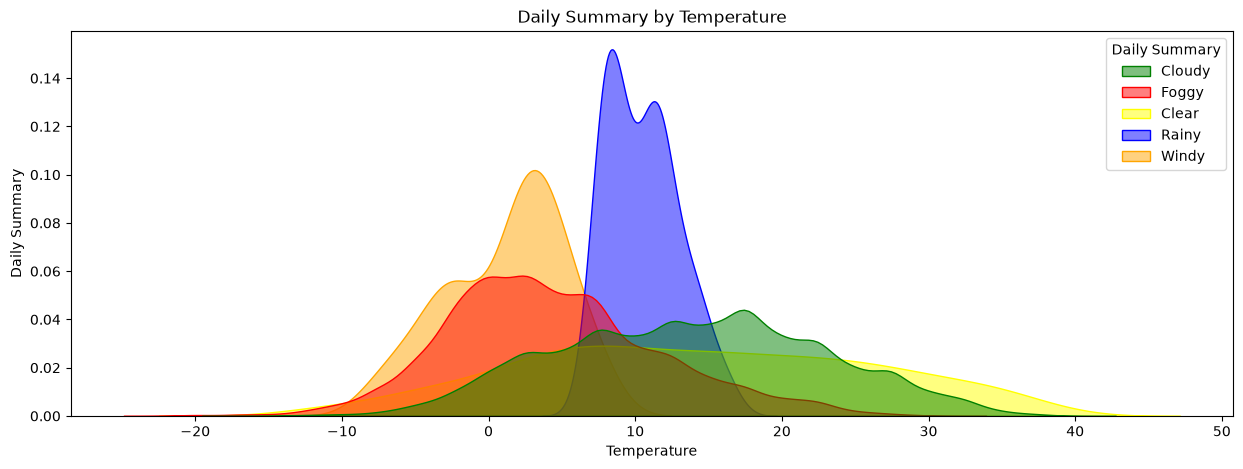

In [178]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='Temperature (C)', hue='Daily Summary', fill=True, common_norm=False, palette={'Cloudy': 'green', 'Foggy': 'red', 'Clear': 'yellow', 'Rainy': 'blue', 'Windy': 'orange'}, alpha=0.5)
plt.title("Daily Summary by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Daily Summary")
plt.show()

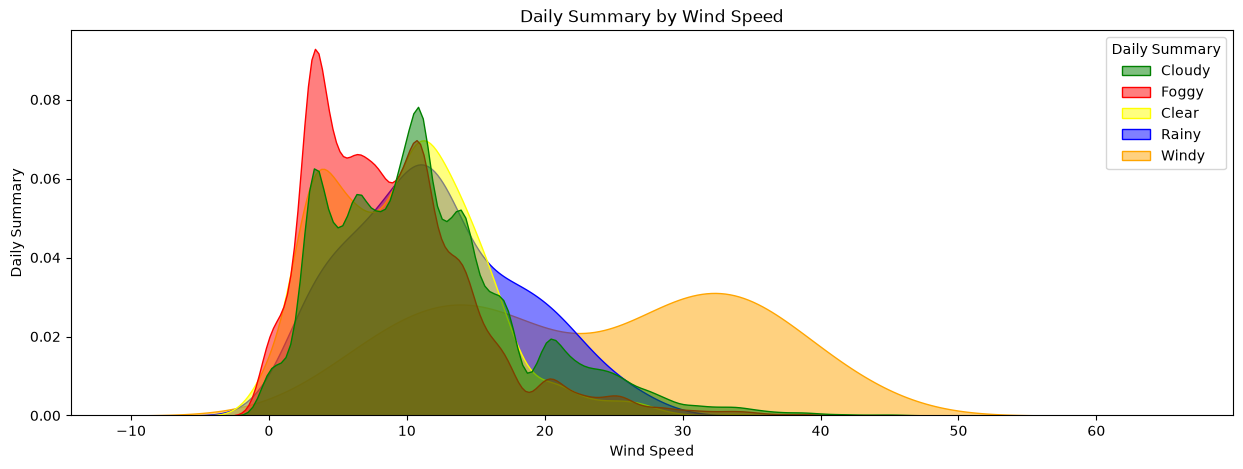

In [179]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=df, x='Wind Speed (km/h)', hue='Daily Summary', fill=True, common_norm=False, palette={'Cloudy': 'green', 'Foggy': 'red', 'Clear': 'yellow', 'Rainy': 'blue', 'Windy': 'orange'}, alpha=0.5)
plt.title("Daily Summary by Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Daily Summary")
plt.show()

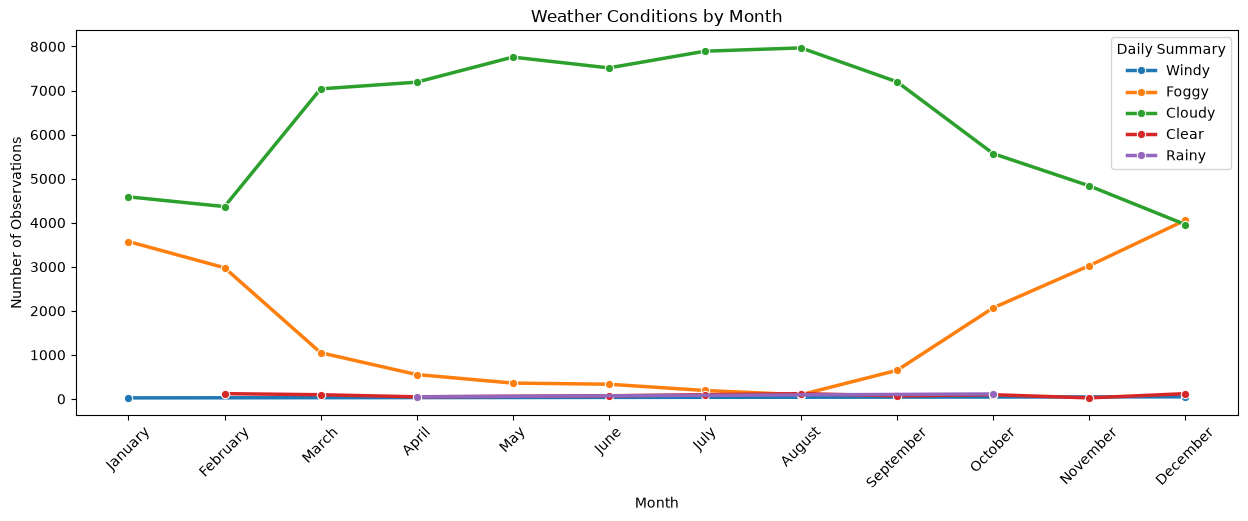

In [180]:
df['Month'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.month_name()
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_data = (df.groupby(['Month', 'Daily Summary']).size().reset_index(name='Count'))

monthly_data['Month'] = pd.Categorical(monthly_data['Month'],categories=month_order,ordered=True)

monthly_data = monthly_data.sort_values('Month')

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_data,
    x='Month',
    y='Count',
    hue='Daily Summary',
    marker='o',
    linewidth=2.5
)

plt.title("Weather Conditions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.show()

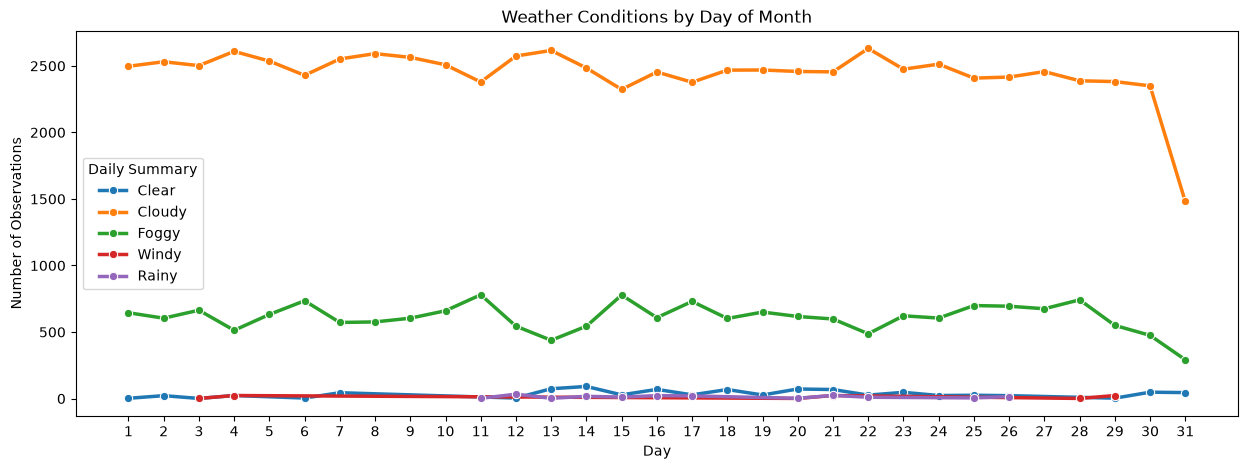

In [181]:
df['Date'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.day
date_order = list(range(1, 32))

daily_data = (
    df.groupby(['Date', 'Daily Summary'])
      .size()
      .reset_index(name='Count')
)

daily_data['Date'] = pd.Categorical(
    daily_data['Date'],
    categories=date_order,
    ordered=True
)

daily_data = daily_data.sort_values('Date')

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=daily_data,
    x='Date',
    y='Count',
    hue='Daily Summary',
    marker='o',
    linewidth=2.5
)

plt.title("Weather Conditions by Day of Month")
plt.xlabel("Day")
plt.ylabel("Number of Observations")
plt.xticks(range(1, 32))
plt.show()

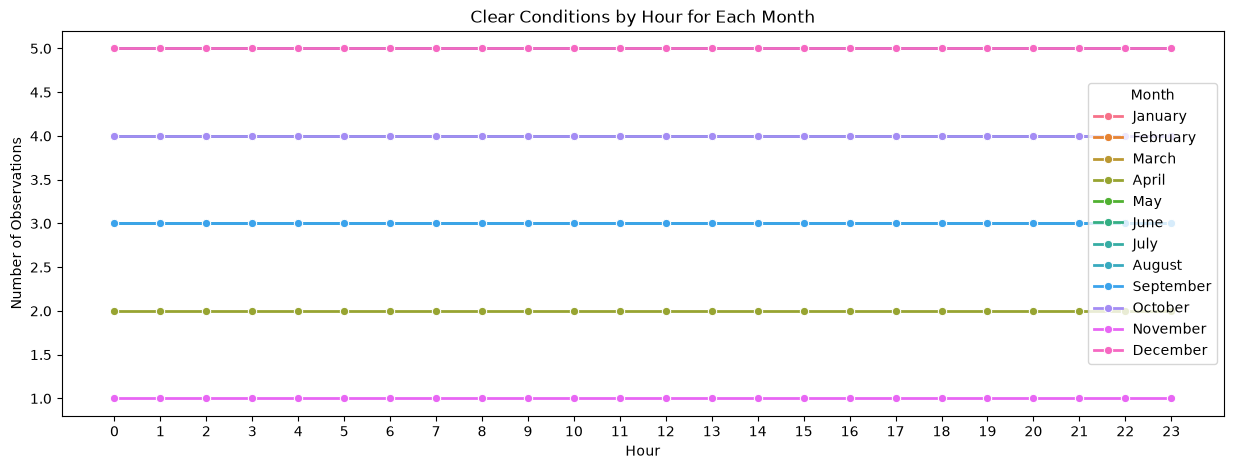

In [182]:
df['Hour'] = pd.to_datetime(
    df['Formatted Date'],
    utc=True
).dt.hour
monthly_hour = (
    df[df['Daily Summary'] == 'Clear']
    .groupby(['Month', 'Hour'])
    .size()
    .reset_index(name='Count')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Count',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Clear Conditions by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Number of Observations")
plt.xticks(range(24))
plt.show()

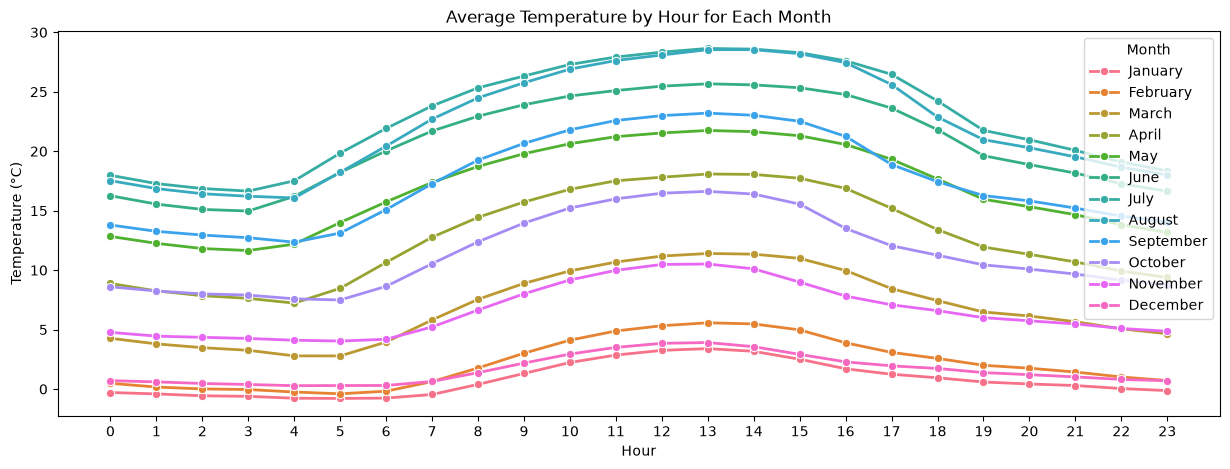

In [183]:
monthly_hour = (
    df.groupby(['Month', 'Hour'])['Temperature (C)']
      .mean()
      .reset_index(name='Temperature')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Temperature',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Temperature by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.xticks(range(24))
plt.show()

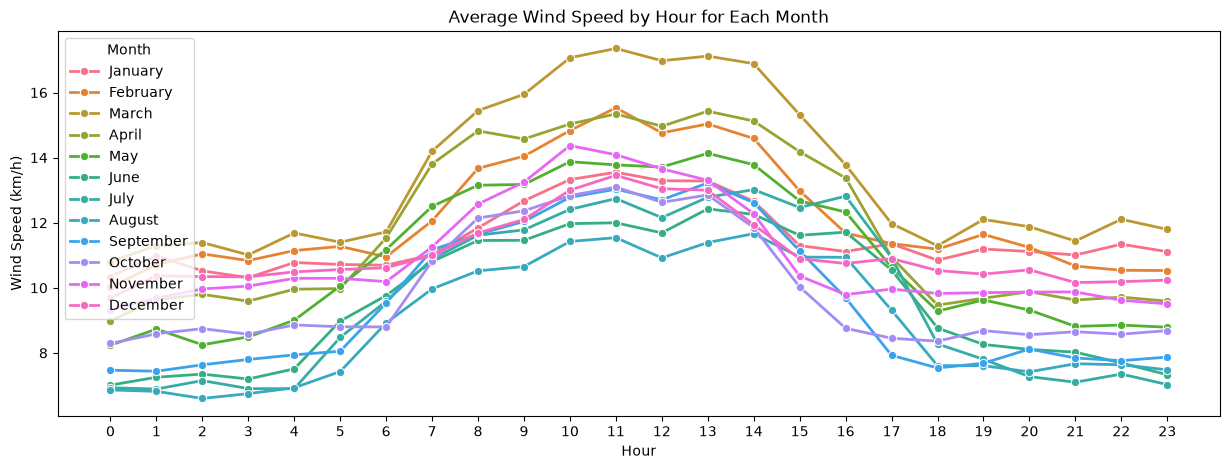

In [184]:
monthly_hour = (
    df.groupby(['Month', 'Hour'])['Wind Speed (km/h)']
      .mean()
      .reset_index(name='Wind Speed')
)

monthly_hour['Month'] = pd.Categorical(
    monthly_hour['Month'],
    categories=month_order,
    ordered=True
)

monthly_hour = monthly_hour.sort_values(['Month', 'Hour'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_hour,
    x='Hour',
    y='Wind Speed',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Wind Speed by Hour for Each Month")
plt.xlabel("Hour")
plt.ylabel("Wind Speed (km/h)")
plt.xticks(range(24))
plt.show()

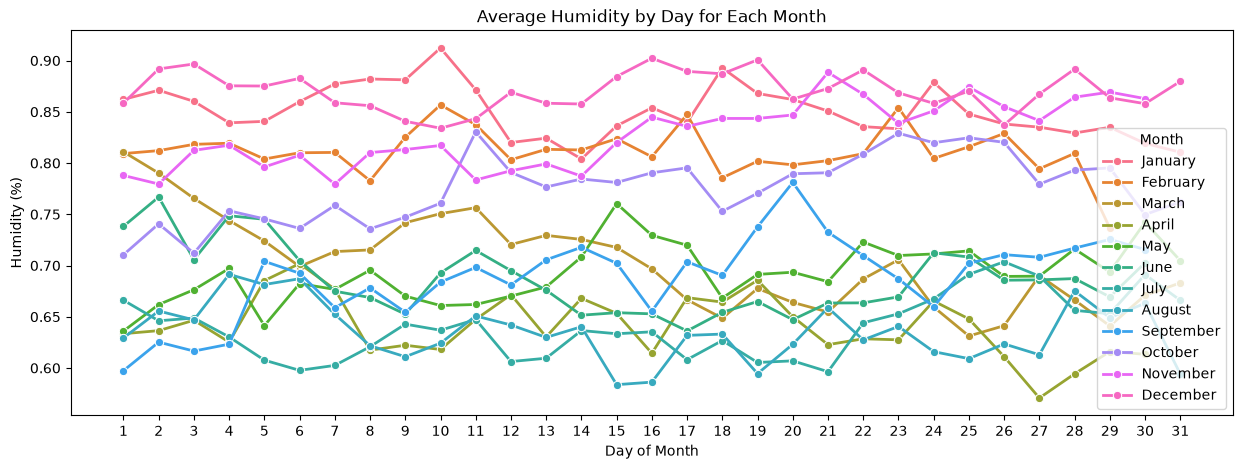

In [185]:
monthly_day = (
    df.groupby(['Month', 'Date'])['Humidity']
      .mean()
      .reset_index(name='Humidity')
)

monthly_day['Month'] = pd.Categorical(
    monthly_day['Month'],
    categories=month_order,
    ordered=True
)

monthly_day = monthly_day.sort_values(['Month', 'Date'])

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=monthly_day,
    x='Date',
    y='Humidity',
    hue='Month',
    marker='o',
    linewidth=2
)

plt.title("Average Humidity by Day for Each Month")
plt.xlabel("Day of Month")
plt.ylabel("Humidity (%)")
plt.xticks(range(1, 32))
plt.show()

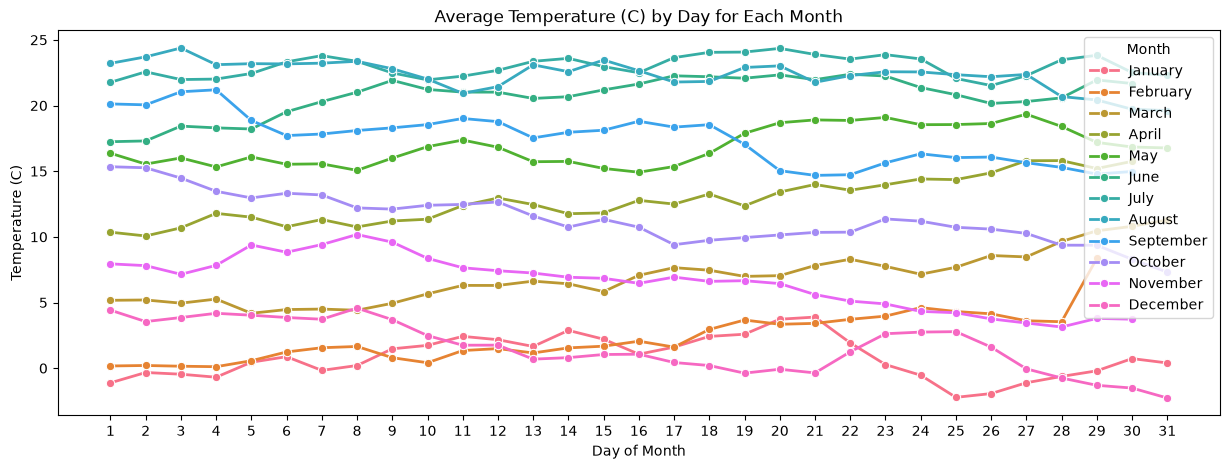

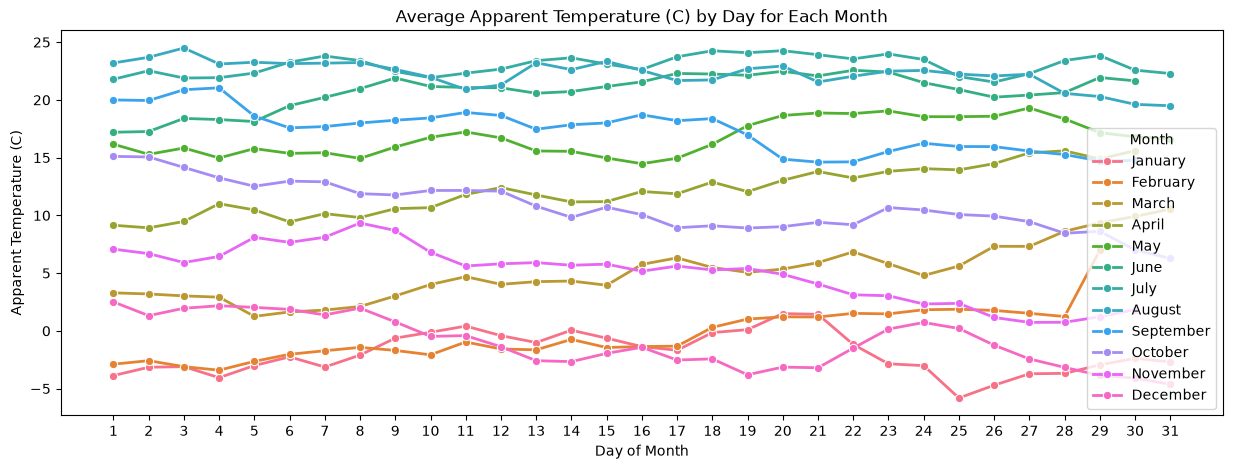

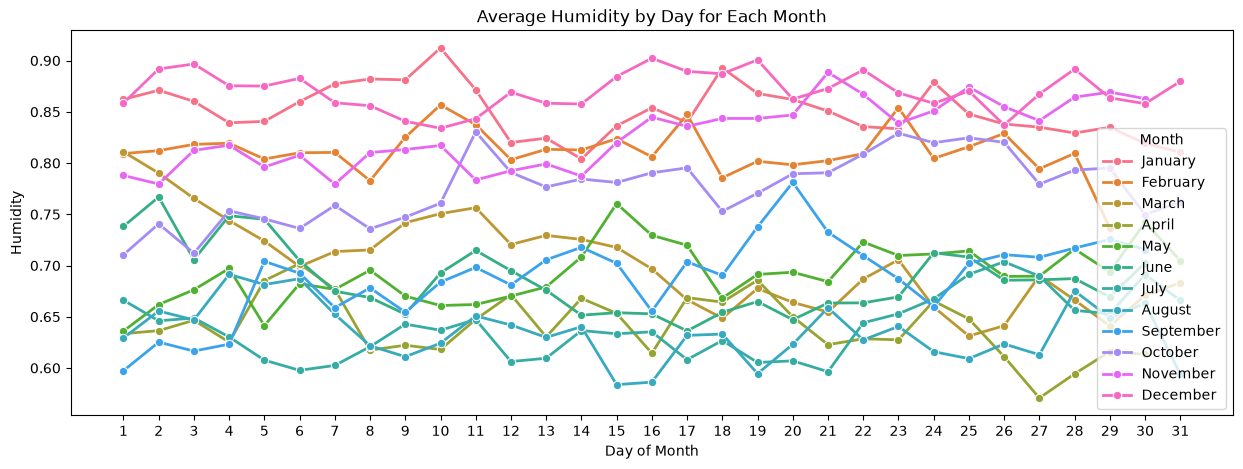

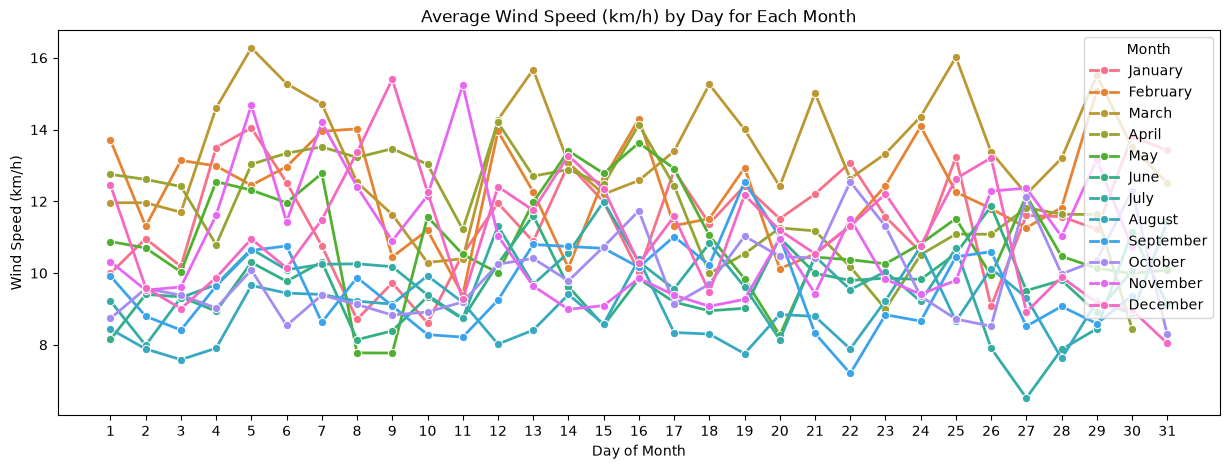

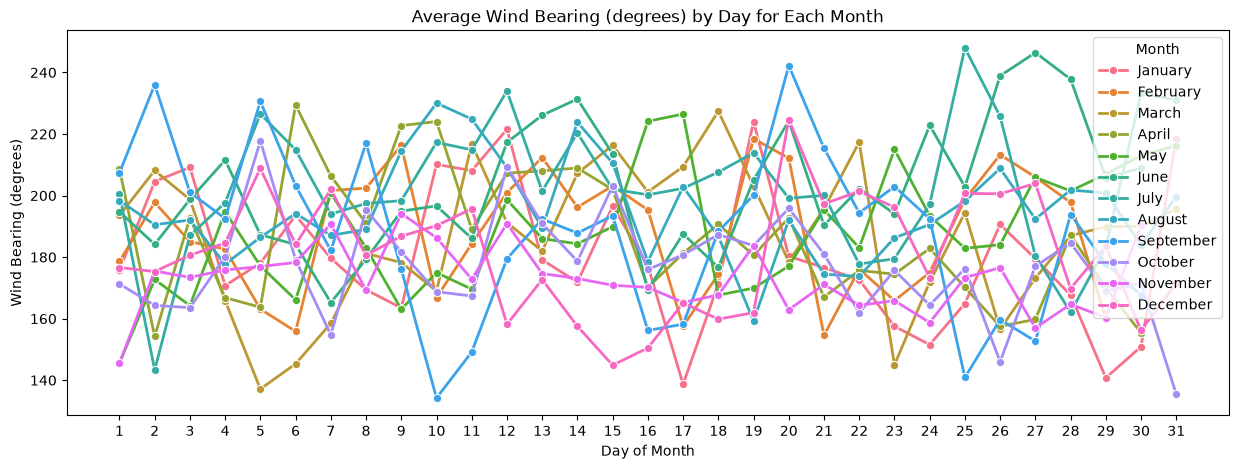

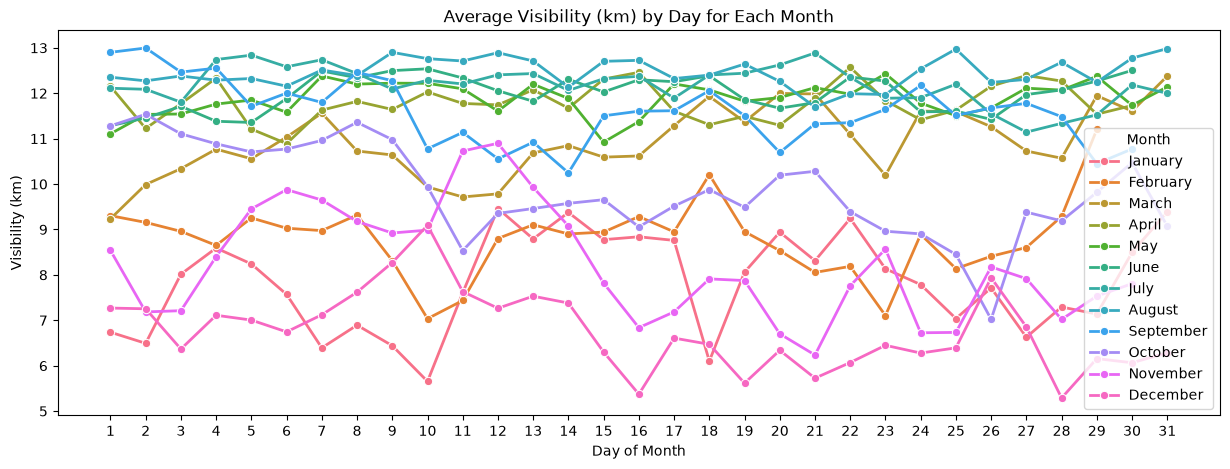

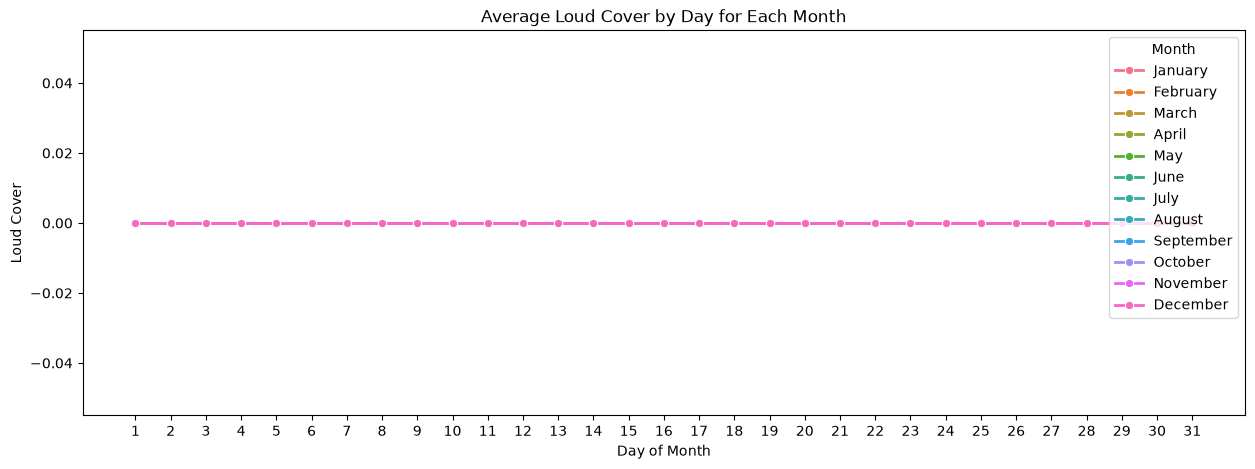

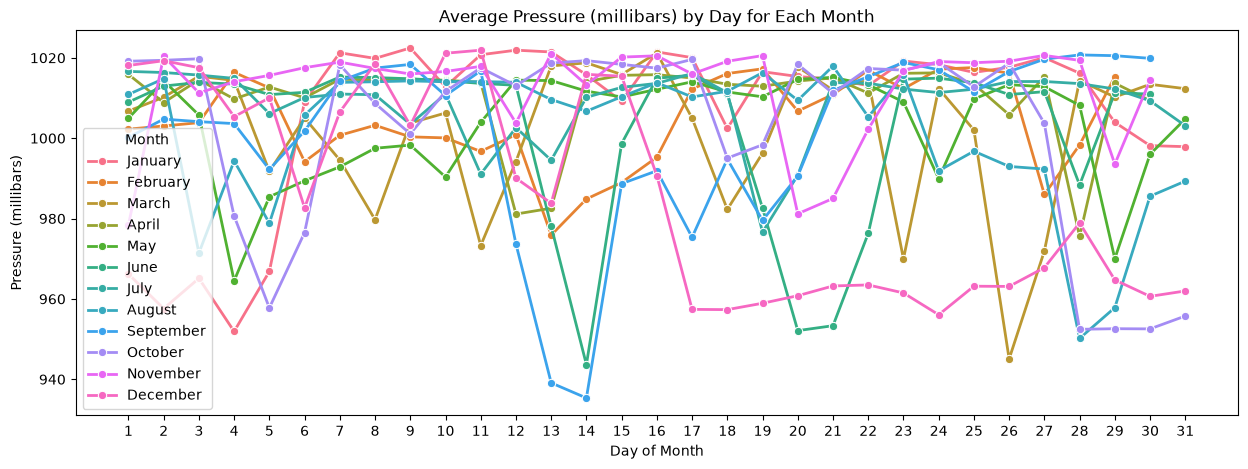

In [186]:
features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Loud Cover',
    'Pressure (millibars)'
]

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

for feature in features:

    monthly_day = (
        df.groupby(['Month', 'Date'])[feature]
          .mean()
          .reset_index(name='Value')
    )

    monthly_day['Month'] = pd.Categorical(
        monthly_day['Month'],
        categories=month_order,
        ordered=True
    )

    monthly_day = monthly_day.sort_values(['Month', 'Date'])

    plt.figure(figsize=(15, 5))

    sns.lineplot(
        data=monthly_day,
        x='Date',
        y='Value',
        hue='Month',
        marker='o',
        linewidth=2
    )

    plt.title(f"Average {feature} by Day for Each Month")
    plt.xlabel("Day of Month")
    plt.ylabel(feature)
    plt.xticks(range(1, 32))
    plt.show()

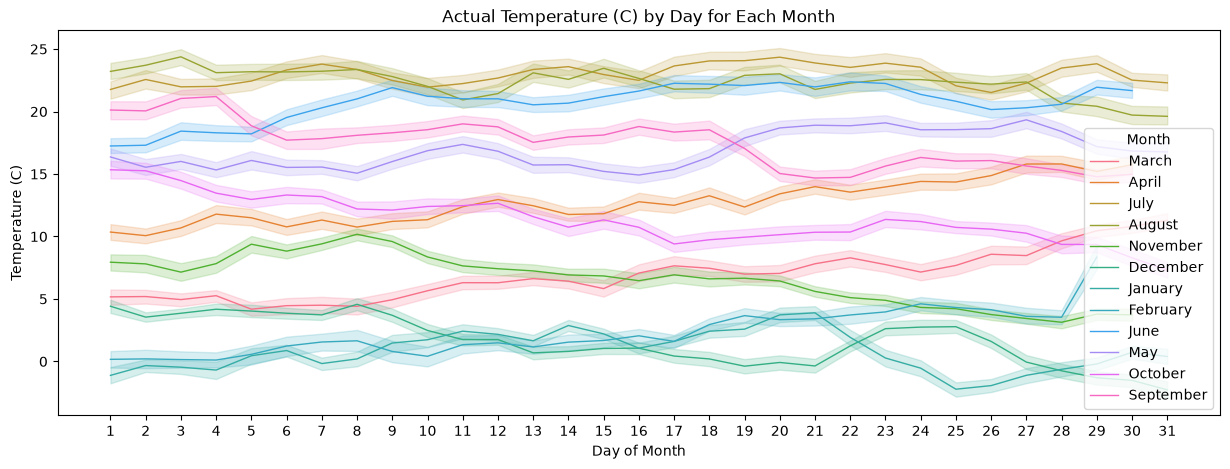

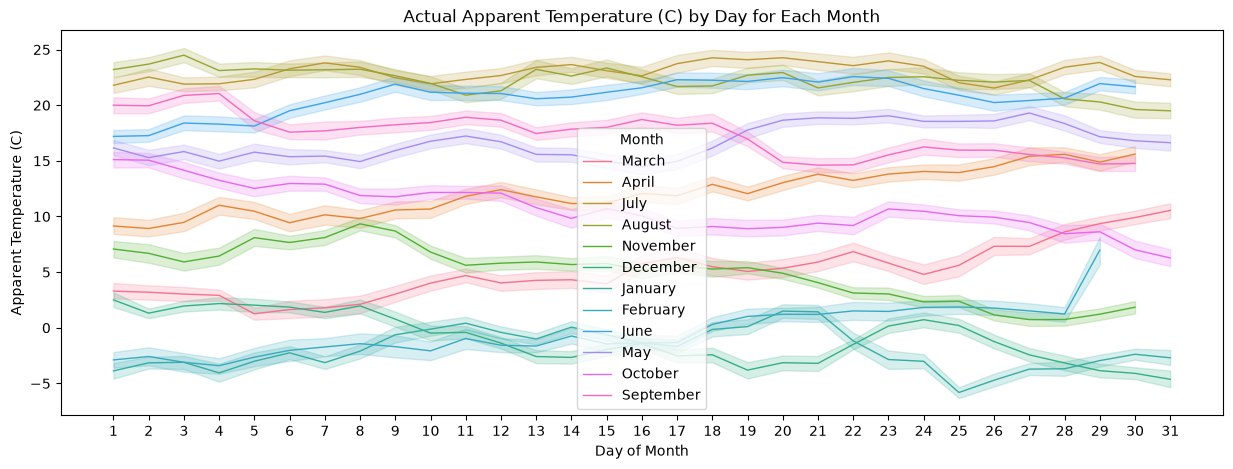

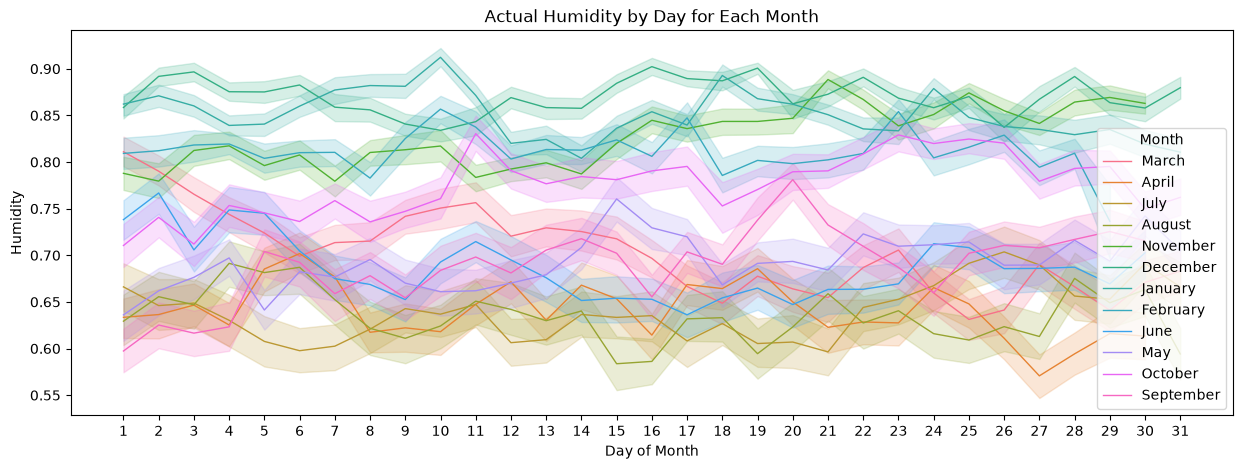

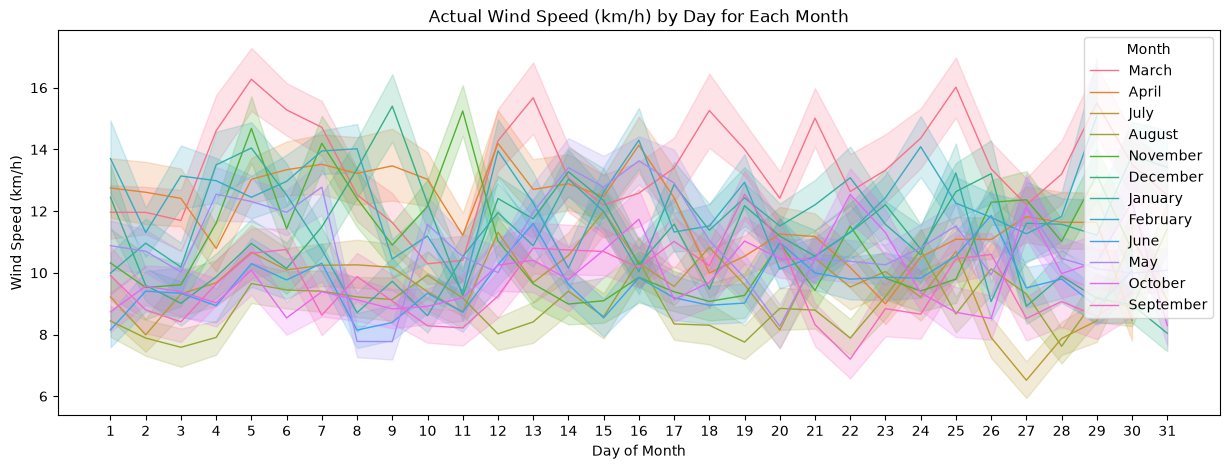

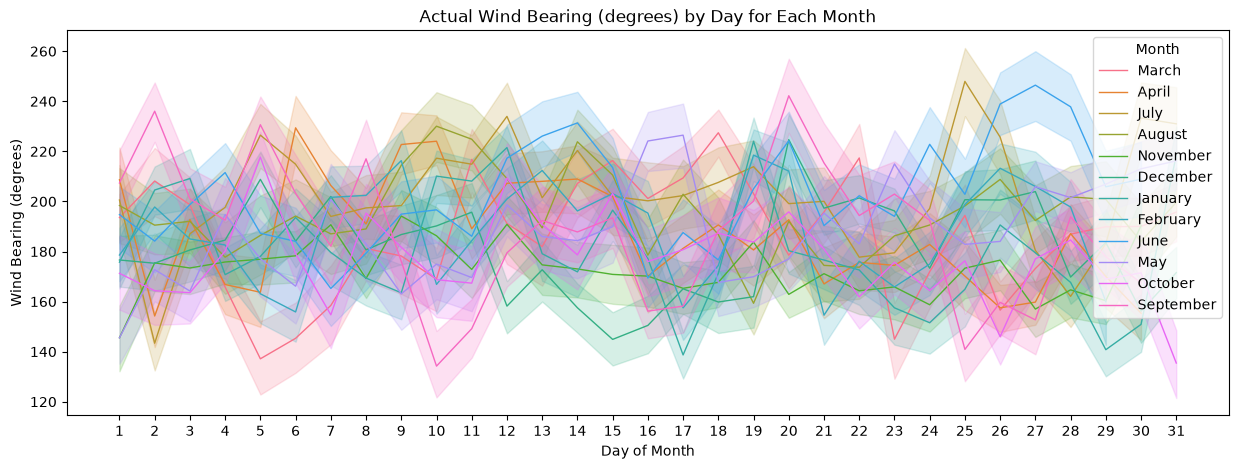

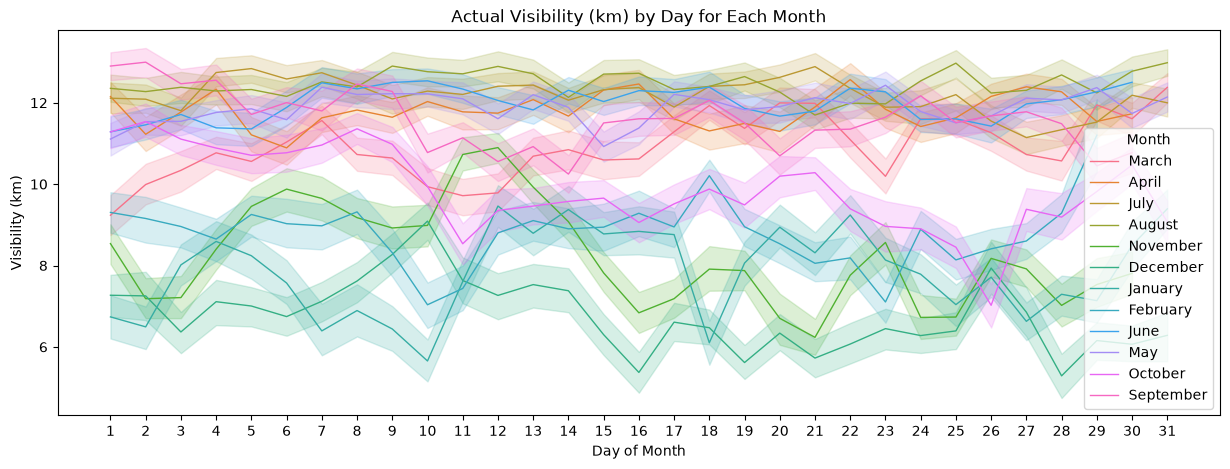

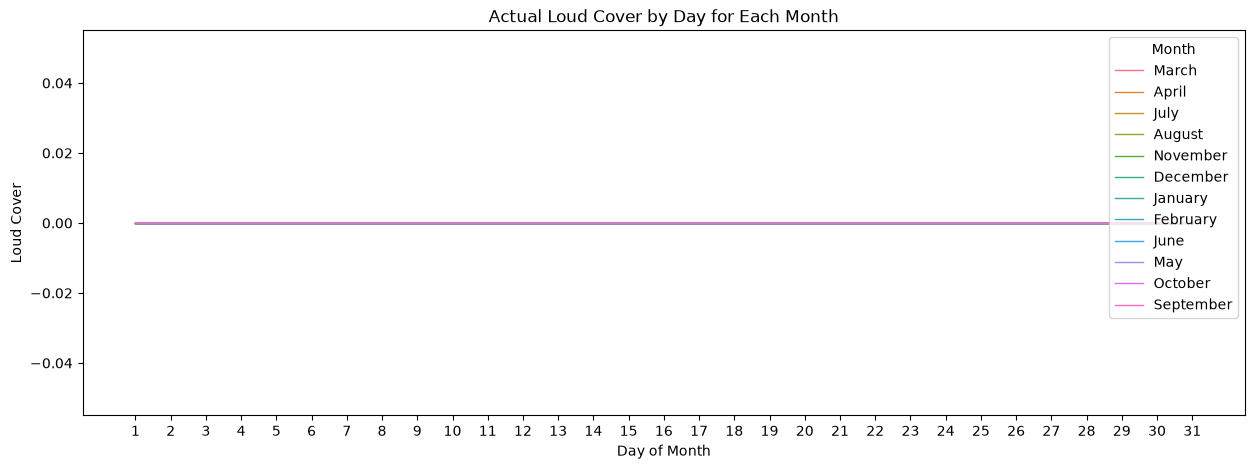

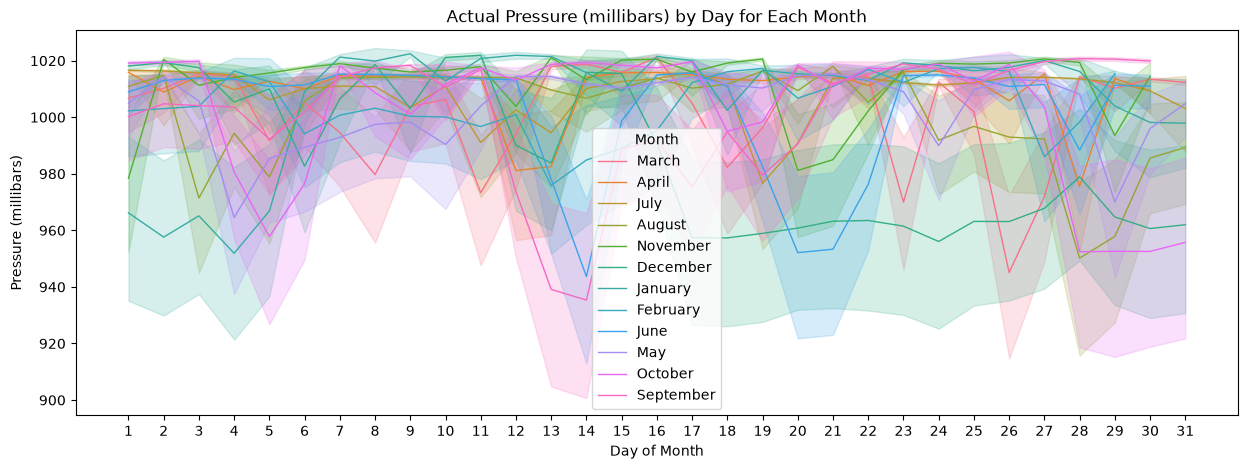

In [187]:
features = [
    'Temperature (C)',
    'Apparent Temperature (C)',
    'Humidity',
    'Wind Speed (km/h)',
    'Wind Bearing (degrees)',
    'Visibility (km)',
    'Loud Cover',
    'Pressure (millibars)'
]

for feature in features:

    plt.figure(figsize=(15, 5))

    sns.lineplot(
        data=df,
        x='Date',
        y=feature,
        hue='Month',
        linewidth=1
    )

    plt.title(f"Actual {feature} by Day for Each Month")
    plt.xlabel("Day of Month")
    plt.ylabel(feature)
    plt.xticks(range(1, 32))
    plt.show()

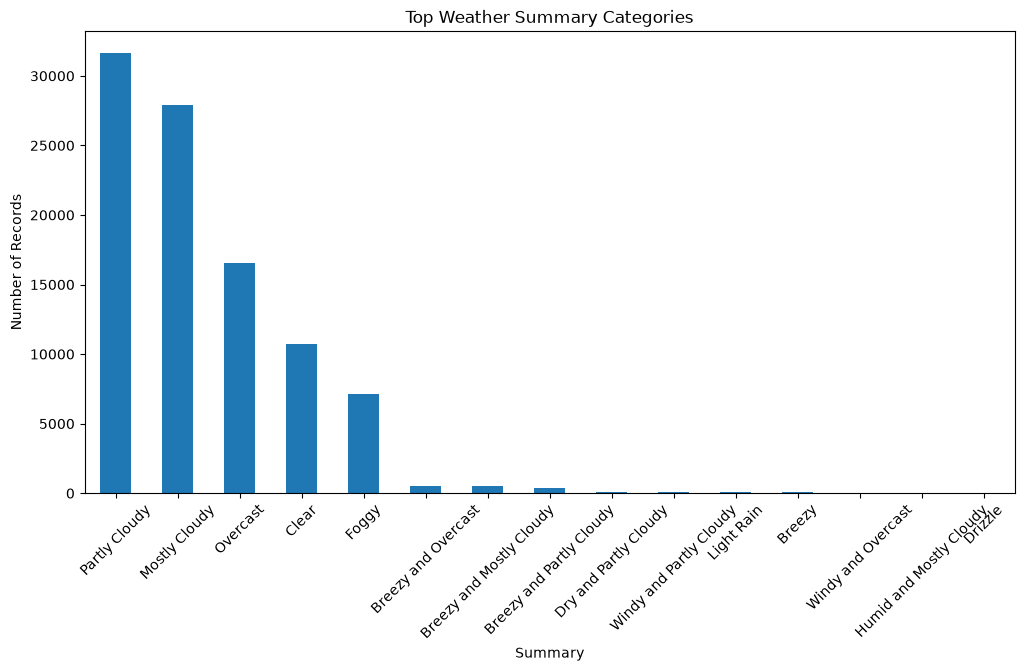

In [188]:
plt.figure(figsize=(12, 6))

df["Summary"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Weather Summary Categories")
plt.xlabel("Summary")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

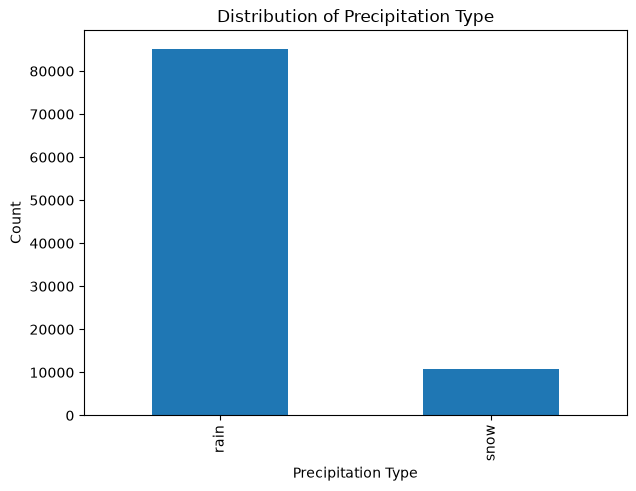

In [189]:
plt.figure(figsize=(7, 5))

df["Precip Type"].value_counts(
    dropna=False
).plot(kind="bar")

plt.title("Distribution of Precipitation Type")
plt.xlabel("Precipitation Type")
plt.ylabel("Count")
plt.show()